In [97]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import theilslopes

### read in exceedance dataframes

In [98]:
ari = 100
duration = 72

version = "v2.0"  ### version of our dataset

In [99]:
if duration > 24:
    st4 = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/stage4/stage4_2002-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    st4 = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/stage4/stage4_2002-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
st4['time'] = pd.to_datetime(st4['time'])

if duration > 24:
    prism = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/prism/prism_1981-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    prism = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/prism/prism_1981-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
prism['time'] = pd.to_datetime(prism['time'])

if duration > 24:
    conus404 = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/conus404/conus404_1981-2022_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    conus404 = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/conus404/conus404_1981-2022_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
conus404['time'] = pd.to_datetime(conus404['time'])

if duration > 24:
    mrms = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/mrms/mrms_2018-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    mrms = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/mrms/mrms_2018-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
mrms['time'] = pd.to_datetime(mrms['time'])

conus404

,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
0,1981-04-14 12:00:00,41.29167,-84.91667,164.645,2.249,1.01385,1
1,1981-04-15 12:00:00,30.54167,-102.70833,217.724,7.691,1.03662,0
2,1981-05-13 12:00:00,45.00000,-112.75000,85.103,2.324,1.02808,2
3,1981-05-13 12:00:00,45.04167,-112.70833,85.854,2.821,1.03398,2
4,1981-05-13 12:00:00,45.66667,-112.20833,68.877,1.846,1.02754,2
...,...,...,...,...,...,...,...
168460,2022-09-30 12:00:00,29.62500,-81.16667,405.774,6.061,1.01516,0
168461,2022-09-30 12:00:00,29.66667,-81.33333,402.595,12.504,1.03205,0
168462,2022-09-30 12:00:00,29.66667,-81.29167,408.180,14.186,1.03600,0
168463,2022-09-30 12:00:00,29.70833,-81.33333,393.734,3.816,1.00979,0


## 2-panel, PRISM vs CONUS404 over longer period, ST4 vs CONUS404 over shorter period, monthly distribution

In [100]:
prism_sub = prism[prism.time < pd.Timestamp(2022,10,1,0)]

### make a combined dataframe that has the 'month' column along with an identifier of the dataset
prism_monthdist = pd.DataFrame(prism_sub.time.dt.month)
prism_monthdist['dataset'] = 'PRISM'

conus404_monthdist = pd.DataFrame(conus404.time.dt.month)
conus404_monthdist['dataset'] = 'CONUS404'

monthdist_long = pd.concat([prism_monthdist,conus404_monthdist])

### shorter period
st4_sub = st4[st4.time < pd.Timestamp(2022,10,1,0)]
conus404_sub = conus404[(conus404.time >= pd.Timestamp(2002,1,1,0))]

### make a combined dataframe that has the 'month' column along with an identifier of the dataset
st4_monthdist = pd.DataFrame(st4_sub.time.dt.month)
st4_monthdist['dataset'] = 'Stage IV'

conus404_sub_monthdist = pd.DataFrame(conus404_sub.time.dt.month)
conus404_sub_monthdist['dataset'] = 'CONUS404'

monthdist_short = pd.concat([st4_monthdist,conus404_sub_monthdist])

monthdist_short



,time,dataset
0,1,Stage IV
1,1,Stage IV
2,1,Stage IV
3,1,Stage IV
4,1,Stage IV
...,...,...
168460,9,CONUS404
168461,9,CONUS404
168462,9,CONUS404
168463,9,CONUS404


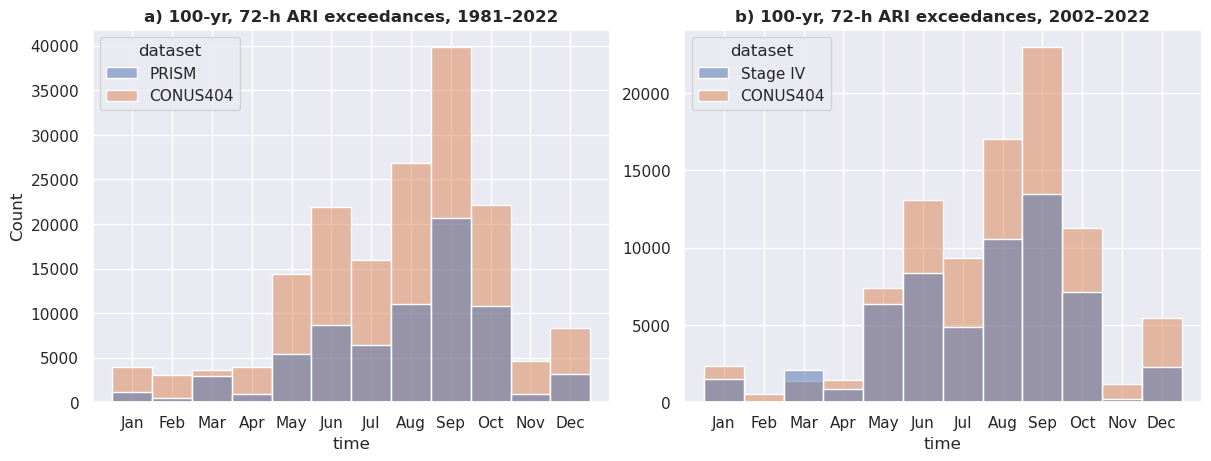

In [101]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(monthdist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(13) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['long'].set_xticks(range(1,13),months)
axes['long'].set_xlim([0, 13])

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(13) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['short'].set_xticks(range(1,13),months)
axes['short'].set_xlim([0, 13])
axes['short'].set_ylabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("monthly_dist_compare_2panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()

plt.close('all')

## repeat, but make it 4-panel with the number of events also

In [102]:
prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_monthdist_events = pd.DataFrame(prism_unique_events.time.unique().month)
prism_monthdist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_monthdist_events = pd.DataFrame(conus404_unique_events.time.unique().month)
conus404_monthdist_events['dataset'] = 'CONUS404'

monthdist_events_long = pd.concat([prism_monthdist_events,conus404_monthdist_events])
monthdist_events_long.columns=['month','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_monthdist_events = pd.DataFrame(st4_unique_events.time.unique().month)
st4_monthdist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_monthdist_events = pd.DataFrame(conus404_unique_events.time.unique().month)
conus404_sub_monthdist_events['dataset'] = 'CONUS404'

monthdist_events_short = pd.concat([st4_monthdist_events,conus404_sub_monthdist_events])
monthdist_events_short.columns=['month','dataset']

monthdist_events_long

,month,dataset
0,6,PRISM
1,6,PRISM
2,8,PRISM
3,8,PRISM
4,8,PRISM
...,...,...
3135,9,CONUS404
3136,9,CONUS404
3137,9,CONUS404
3138,9,CONUS404


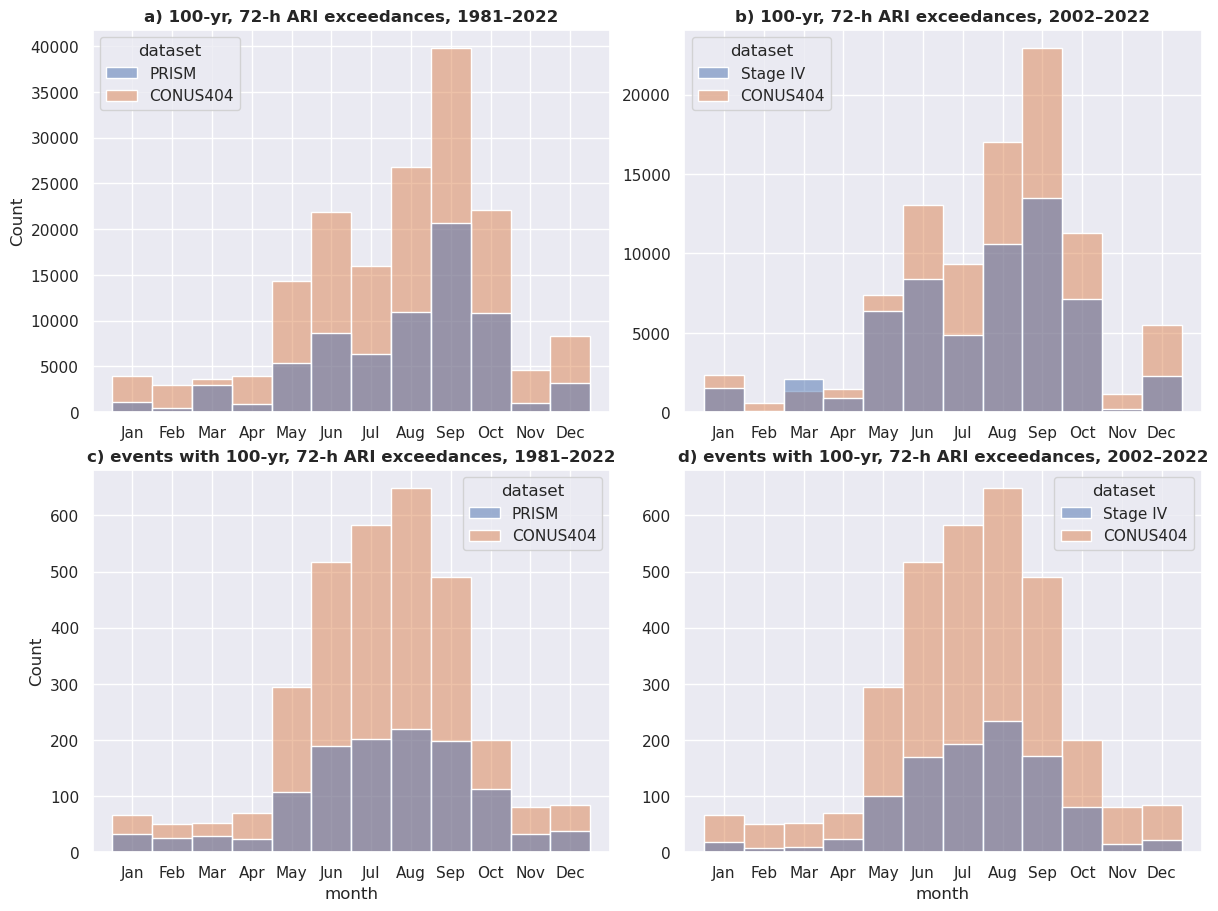

In [103]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short']], figsize=(12,9),
                              constrained_layout=True)

sns.histplot(monthdist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(13) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['long'].set_xticks(range(1,13),months)
axes['long'].set_xlim([0, 13])
axes['long'].set_xlabel('')

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(13) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['short'].set_xticks(range(1,13),months)
axes['short'].set_xlim([0, 13])
axes['short'].set_ylabel('')
axes['short'].set_xlabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

### events
sns.histplot(monthdist_events_long, x='month', hue='dataset', ax=axes['events_long'],
             bins = np.arange(13) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_long'].set_xticks(range(1,13),months)
axes['events_long'].set_xlim([0, 13])

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_events_short, x='month', hue='dataset', ax=axes['events_short'],
             bins = np.arange(13) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_short'].set_xticks(range(1,13),months)
axes['events_short'].set_xlim([0, 13])
axes['events_short'].set_ylabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("monthly_dist_compare_4panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()

plt.close('all')

### or 6-panel, with # of points per event on the bottom

#### calculate the points per event

In [104]:
bin_edges = np.histogram_bin_edges(monthdist_long['time'], bins=np.arange(13) + 0.5)

weights = []
for dataset, group in monthdist_long.groupby('dataset', sort=False):
    events_group = monthdist_events_long[monthdist_events_long['dataset'] == dataset]
    
    # Count rows per bin in each dataframe
    total_per_bin, _ = np.histogram(group['time'], bins=bin_edges)
    unique_per_bin, _ = np.histogram(events_group['month'], bins=bin_edges)
    
    # Weight = (total/unique) per bin, normalized by total so bin sum = total/unique
    ratio_per_bin = total_per_bin / np.maximum(unique_per_bin, 1)
    row_bin_indices = np.clip(np.digitize(group['time'], bin_edges) - 1, 0, len(bin_edges) - 2)
    #row_weights = ratio_per_bin[row_bin_indices] / total_per_bin[row_bin_indices]
    row_weights = ratio_per_bin[row_bin_indices] / np.maximum(total_per_bin[row_bin_indices], 1)
    
    weights.append(pd.Series(row_weights, index=group.index))

monthdist_long['weight'] = pd.concat(weights)

### repeat for the 'short' dataset
weights = []
for dataset, group in monthdist_short.groupby('dataset', sort=False):
    events_group = monthdist_events_short[monthdist_events_short['dataset'] == dataset]
    
    # Count rows per bin in each dataframe
    total_per_bin, _ = np.histogram(group['time'], bins=bin_edges)
    unique_per_bin, _ = np.histogram(events_group['month'], bins=bin_edges)
    
    # Weight = (total/unique) per bin, normalized by total so bin sum = total/unique
    ratio_per_bin = total_per_bin / np.maximum(unique_per_bin, 1)
    row_bin_indices = np.clip(np.digitize(group['time'], bin_edges) - 1, 0, len(bin_edges) - 2)
    #row_weights = ratio_per_bin[row_bin_indices] / total_per_bin[row_bin_indices]
    row_weights = ratio_per_bin[row_bin_indices] / np.maximum(total_per_bin[row_bin_indices], 1)
    
    weights.append(pd.Series(row_weights, index=group.index))

monthdist_short['weight'] = pd.concat(weights)

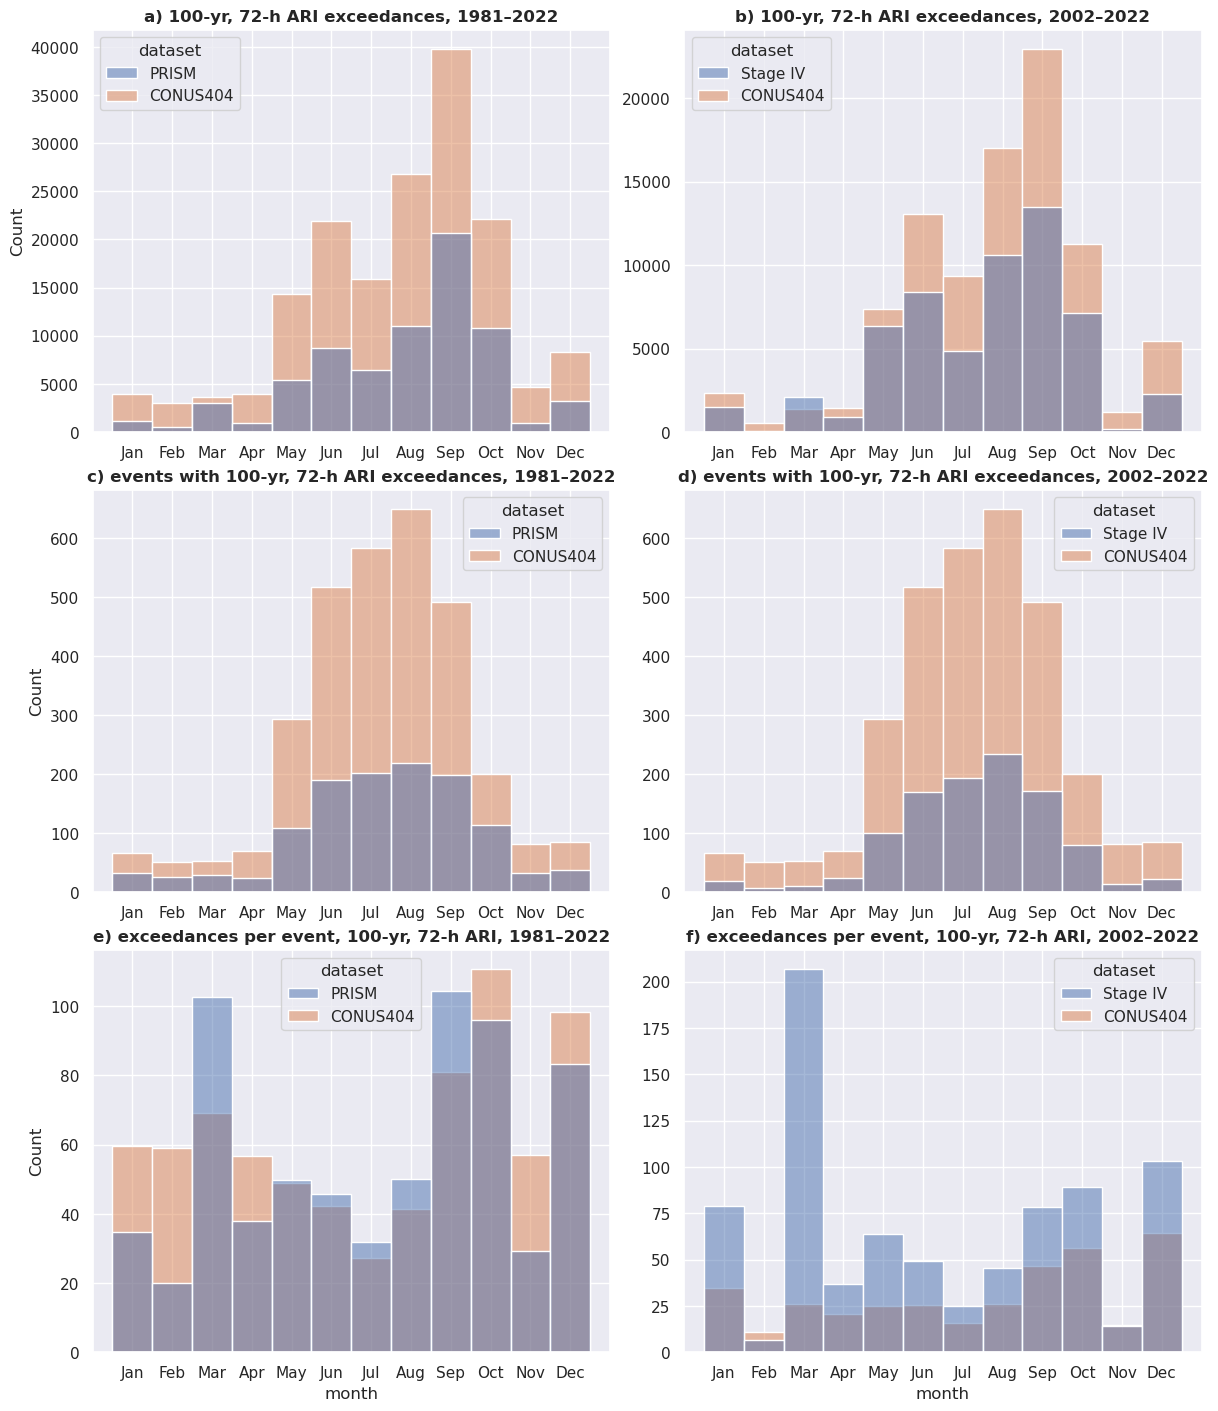

In [105]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short'],
                               ['pointsper_long','pointsper_short']], figsize=(12,14),
                              constrained_layout=True)

sns.histplot(monthdist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(13) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['long'].set_xticks(range(1,13),months)
axes['long'].set_xlim([0, 13])
axes['long'].set_xlabel('')

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(13) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['short'].set_xticks(range(1,13),months)
axes['short'].set_xlim([0, 13])
axes['short'].set_ylabel('')
axes['short'].set_xlabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

### events
sns.histplot(monthdist_events_long, x='month', hue='dataset', ax=axes['events_long'],
             bins = np.arange(13) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_long'].set_xticks(range(1,13),months)
axes['events_long'].set_xlim([0, 13])
axes['events_long'].set_xlabel('')

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_events_short, x='month', hue='dataset', ax=axes['events_short'],
             bins = np.arange(13) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_short'].set_xticks(range(1,13),months)
axes['events_short'].set_xlim([0, 13])
axes['events_short'].set_ylabel('')
axes['events_short'].set_xlabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

### and points per event
sns.histplot(monthdist_long, x='time', hue='dataset', weights='weight', ax=axes['pointsper_long'],
             bins = list(np.arange(13) + 0.5)).set_title("e) exceedances per event, "+str(ari)+"-yr, "+str(duration)+"-h ARI, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
axes['pointsper_long'].set_xticks(range(1,13),months)
axes['pointsper_long'].set_xlim([0, 13])
axes['pointsper_long'].set_xlabel('month')

sns.histplot(monthdist_short, x='time', hue='dataset', weights='weight', ax=axes['pointsper_short'],
             bins = list(np.arange(13) + 0.5)).set_title("f) exceedances per event, "+str(ari)+"-yr, "+str(duration)+"-h ARI, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
axes['pointsper_short'].set_xticks(range(1,13),months)
axes['pointsper_short'].set_xlim([0, 13])
axes['pointsper_short'].set_xlabel('month')
axes['pointsper_short'].set_ylabel('')


plt.savefig("monthly_dist_compare_6panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()

plt.close('all')

## 4-panel, time series of exceedance comparison on top; event number comparison on bottom

In [106]:
prism_yeardist = pd.DataFrame(prism_sub.time.dt.year)
prism_yeardist['dataset'] = 'PRISM'

conus404_yeardist = pd.DataFrame(conus404.time.dt.year)
conus404_yeardist['dataset'] = 'CONUS404'

yeardist_long = pd.concat([prism_yeardist,conus404_yeardist])

st4_yeardist = pd.DataFrame(st4_sub.time.dt.year)
st4_yeardist['dataset'] = 'Stage IV'

conus404_sub_yeardist = pd.DataFrame(conus404_sub.time.dt.year)
conus404_sub_yeardist['dataset'] = 'CONUS404'

yeardist_short = pd.concat([st4_yeardist,conus404_sub_yeardist])

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_long = pd.concat([prism_yeardist_events,conus404_yeardist_events])
yeardist_events_long.columns=['year','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_sub_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_short = pd.concat([st4_yeardist_events,conus404_sub_yeardist_events])
yeardist_events_short.columns=['year','dataset']

yeardist_events_short



,year,dataset
0,2002,Stage IV
1,2002,Stage IV
2,2002,Stage IV
3,2002,Stage IV
4,2002,Stage IV
...,...,...
3135,2022,CONUS404
3136,2022,CONUS404
3137,2022,CONUS404
3138,2022,CONUS404


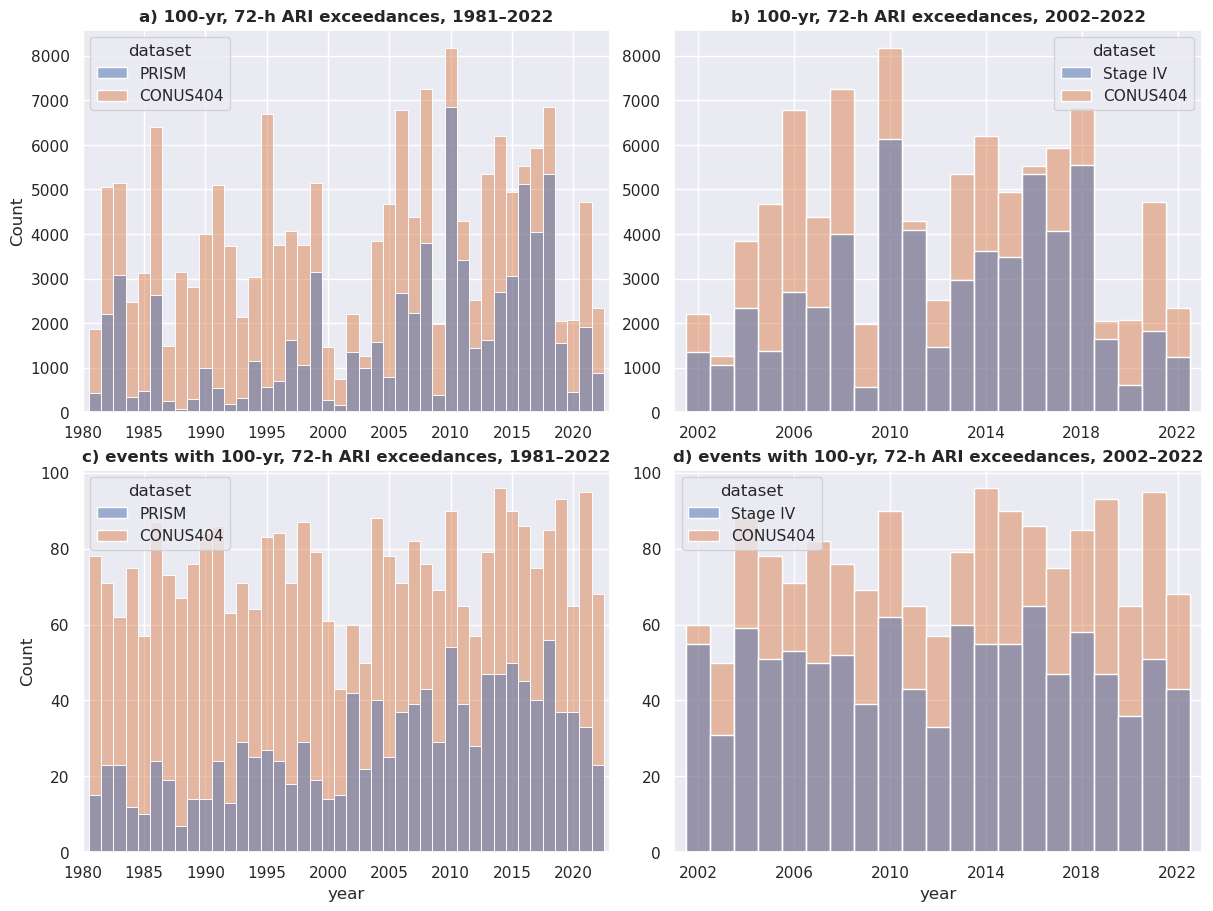

In [107]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short']], figsize=(12,9),
                              constrained_layout=True)

sns.histplot(yeardist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(1980,2023) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['long'].set_xlim([1980, 2023])
axes['long'].set_xlabel('')

sns.histplot(yeardist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(2001,2023) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['short'].set_xlim([2001, 2023])
axes['short'].set_xticks(range(2002,2023,4))
axes['short'].set_xlabel('')
axes['short'].set_ylabel('')

sns.histplot(yeardist_events_long, x='year', hue='dataset', ax=axes['events_long'],
             bins = np.arange(1980,2023) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_long'].set_xlim([1980, 2023])

sns.histplot(yeardist_events_short, x='year', hue='dataset', ax=axes['events_short'],
             bins = np.arange(2001,2023) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_short'].set_xlim([2001, 2023])
axes['events_short'].set_xticks(range(2002,2023,4))
axes['events_short'].set_ylabel('')

plt.savefig("annual_dist_compare_4panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()
plt.close('all')



### and 6-panel version of the same, with points per event underneath

#### get points per event

In [108]:
bin_edges = np.histogram_bin_edges(yeardist_long['time'], bins=np.arange(1980,2023) + 0.5)

weights = []
for dataset, group in yeardist_long.groupby('dataset', sort=False):
    events_group = yeardist_events_long[yeardist_events_long['dataset'] == dataset]
    
    # Count rows per bin in each dataframe
    total_per_bin, _ = np.histogram(group['time'], bins=bin_edges)
    unique_per_bin, _ = np.histogram(events_group['year'], bins=bin_edges)
    
    # Weight = (total/unique) per bin, normalized by total so bin sum = total/unique
    ratio_per_bin = total_per_bin / np.maximum(unique_per_bin, 1)
    row_bin_indices = np.clip(np.digitize(group['time'], bin_edges) - 1, 0, len(bin_edges) - 2)
    #row_weights = ratio_per_bin[row_bin_indices] / total_per_bin[row_bin_indices]
    row_weights = ratio_per_bin[row_bin_indices] / np.maximum(total_per_bin[row_bin_indices], 1)
    
    weights.append(pd.Series(row_weights, index=group.index))

yeardist_long['weight'] = pd.concat(weights)

### repeat for the 'short' dataset
bin_edges = np.histogram_bin_edges(yeardist_short['time'], bins=np.arange(2002,2023) + 0.5)
weights = []
for dataset, group in yeardist_short.groupby('dataset', sort=False):
    events_group = yeardist_events_short[yeardist_events_short['dataset'] == dataset]
    
    # Count rows per bin in each dataframe
    total_per_bin, _ = np.histogram(group['time'], bins=bin_edges)
    unique_per_bin, _ = np.histogram(events_group['year'], bins=bin_edges)
    
    # Weight = (total/unique) per bin, normalized by total so bin sum = total/unique
    ratio_per_bin = total_per_bin / np.maximum(unique_per_bin, 1)
    row_bin_indices = np.clip(np.digitize(group['time'], bin_edges) - 1, 0, len(bin_edges) - 2)
    #row_weights = ratio_per_bin[row_bin_indices] / total_per_bin[row_bin_indices]
    row_weights = ratio_per_bin[row_bin_indices] / np.maximum(total_per_bin[row_bin_indices], 1)
    
    weights.append(pd.Series(row_weights, index=group.index))

yeardist_short['weight'] = pd.concat(weights)

In [109]:
yeardist_short

,time,dataset,weight
0,2002,Stage IV,0.032258
1,2002,Stage IV,0.032258
2,2002,Stage IV,0.032258
3,2002,Stage IV,0.032258
4,2002,Stage IV,0.032258
...,...,...,...
168460,2022,CONUS404,0.014706
168461,2022,CONUS404,0.014706
168462,2022,CONUS404,0.014706
168463,2022,CONUS404,0.014706


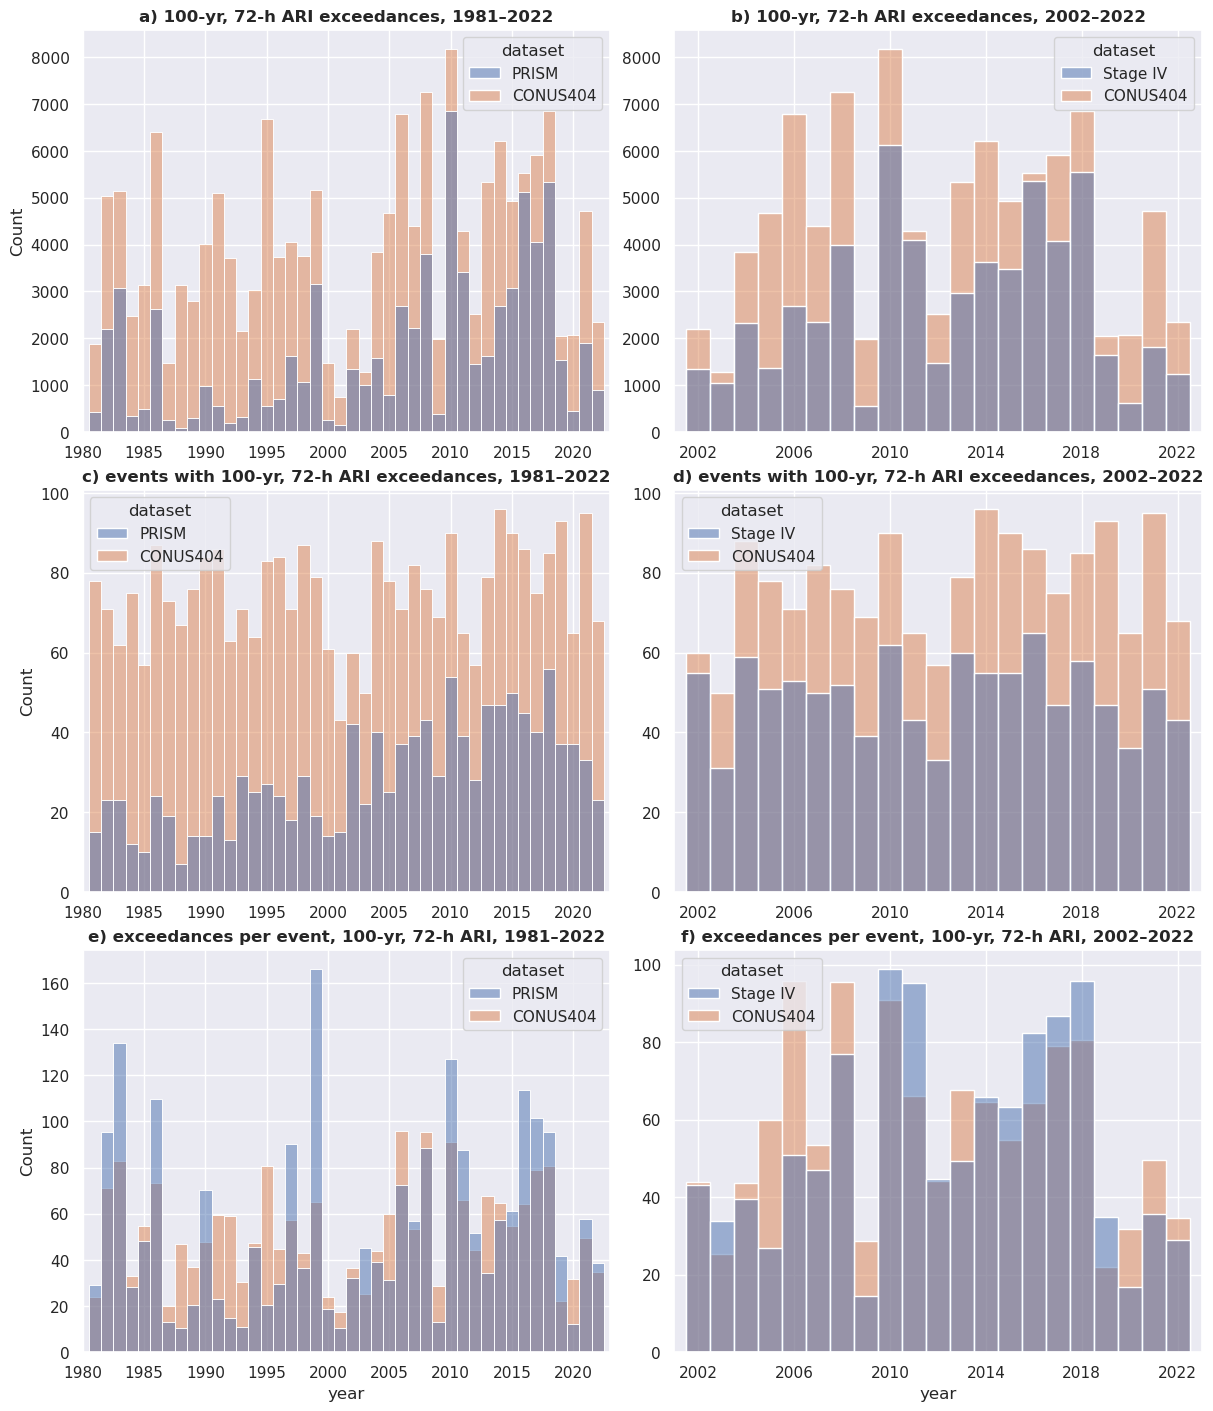

In [110]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short'],
                               ['pointsper_long','pointsper_short']], figsize=(12,14),
                              constrained_layout=True)

sns.histplot(yeardist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(1980,2023) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['long'].set_xlim([1980, 2023])
axes['long'].set_xlabel('')

sns.histplot(yeardist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(2001,2023) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['short'].set_xlim([2001, 2023])
axes['short'].set_xticks(range(2002,2023,4))
axes['short'].set_xlabel('')
axes['short'].set_ylabel('')

sns.histplot(yeardist_events_long, x='year', hue='dataset', ax=axes['events_long'],
             bins = np.arange(1980,2023) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_long'].set_xlim([1980, 2023])
axes['events_long'].set_xlabel('')

sns.histplot(yeardist_events_short, x='year', hue='dataset', ax=axes['events_short'],
             bins = np.arange(2001,2023) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_short'].set_xlim([2001, 2023])
axes['events_short'].set_xticks(range(2002,2023,4))
axes['events_short'].set_xlabel('')
axes['events_short'].set_ylabel('')

### and points per event
sns.histplot(yeardist_long, x='time', hue='dataset', weights='weight', ax=axes['pointsper_long'],
             bins = list(np.arange(1980,2023) + 0.5)).set_title("e) exceedances per event, "+str(ari)+"-yr, "+str(duration)+"-h ARI, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
axes['pointsper_long'].set_xlim([1980, 2023])
axes['pointsper_long'].set_xlabel('year')

sns.histplot(yeardist_short, x='time', hue='dataset', weights='weight', ax=axes['pointsper_short'],
             bins = list(np.arange(2001,2023) + 0.5)).set_title("f) exceedances per event, "+str(ari)+"-yr, "+str(duration)+"-h ARI, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
axes['pointsper_short'].set_xlim([2001, 2023])
axes['pointsper_short'].set_xticks(range(2002,2023,4))
axes['pointsper_short'].set_xlabel('year')
axes['pointsper_short'].set_ylabel('')

plt.savefig("annual_dist_compare_6panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()
plt.close('all')



## 2-panel, PRISM vs Stage IV, 2002-2024

In [111]:
st4_sub = st4[st4.time < pd.Timestamp(2025,1,1,0)]
prism_sub = prism[(prism.time >= pd.Timestamp(2002,1,1,0))]

st4_yeardist = pd.DataFrame(st4_sub.time.dt.year)
st4_yeardist['dataset'] = 'Stage IV'

prism_yeardist = pd.DataFrame(prism_sub.time.dt.year)
prism_yeardist['dataset'] = 'PRISM'

yeardist = pd.concat([prism_yeardist,st4_yeardist])

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

yeardist_events = pd.concat([prism_yeardist_events,st4_yeardist_events])
yeardist_events.columns=['year','dataset']

yeardist_events


,year,dataset
0,2002,PRISM
1,2002,PRISM
2,2002,PRISM
3,2002,PRISM
4,2002,PRISM
...,...,...
1158,2024,Stage IV
1159,2024,Stage IV
1160,2024,Stage IV
1161,2024,Stage IV


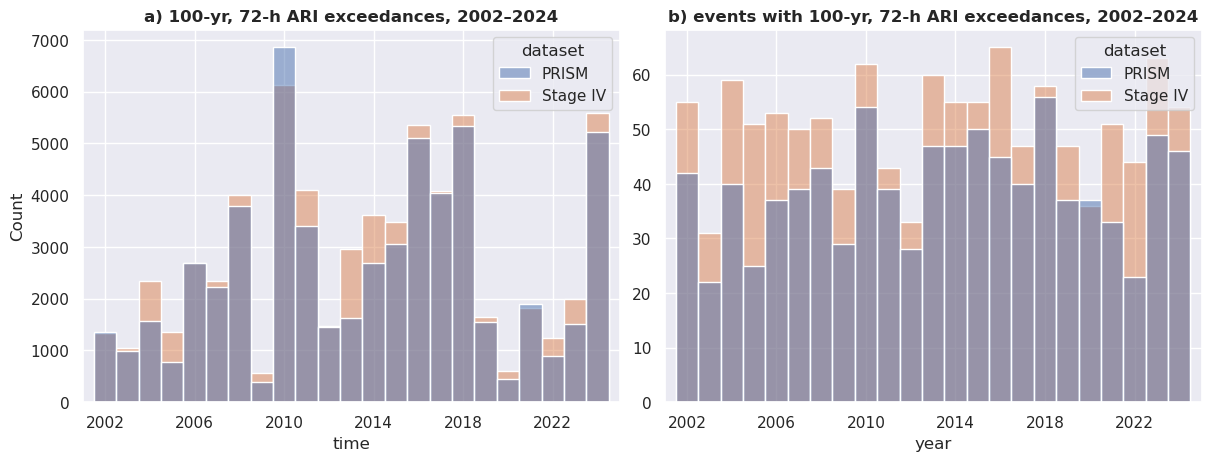

In [112]:
fig, axes = plt.subplot_mosaic([['exceed','events']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(yeardist, x='time', hue='dataset', ax=axes['exceed'],
             bins = np.arange(2001,2025) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132024",
                                                         fontdict={'weight': 'semibold'})
axes['exceed'].set_xticks(range(2002,2025,4))
axes['exceed'].set_xlim(2001,2025)

sns.histplot(yeardist_events, x='year', hue='dataset', ax=axes['events'],
             bins = np.arange(2001,2025) + 0.5).set_title("b) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132024",
                                                         fontdict={'weight': 'semibold'})
axes['events'].set_xticks(range(2002,2025,4))
axes['events'].set_xlim(2001,2025)
axes['events'].set_ylabel('')

plt.savefig("annual_dist_compare_prism_st4_2panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')
plt.show()
plt.close('all')

### and just a separate one for points per event

In [113]:
### repeat for the 'short' dataset
bin_edges = np.histogram_bin_edges(yeardist['time'], bins=np.arange(2001,2025) + 0.5)
weights = []
for dataset, group in yeardist.groupby('dataset', sort=False):
    events_group = yeardist_events[yeardist_events['dataset'] == dataset]
    
    # Count rows per bin in each dataframe
    total_per_bin, _ = np.histogram(group['time'], bins=bin_edges)
    unique_per_bin, _ = np.histogram(events_group['year'], bins=bin_edges)
    
    # Weight = (total/unique) per bin, normalized by total so bin sum = total/unique
    ratio_per_bin = total_per_bin / np.maximum(unique_per_bin, 1)
    row_bin_indices = np.clip(np.digitize(group['time'], bin_edges) - 1, 0, len(bin_edges) - 2)
    #row_weights = ratio_per_bin[row_bin_indices] / total_per_bin[row_bin_indices]
    row_weights = ratio_per_bin[row_bin_indices] / np.maximum(total_per_bin[row_bin_indices], 1)
    
    weights.append(pd.Series(row_weights, index=group.index))

yeardist['weight'] = pd.concat(weights)

Text(0.5, 1.0, 'exceedances per event, 100-yr, 72-h ARI, 2002–2024')

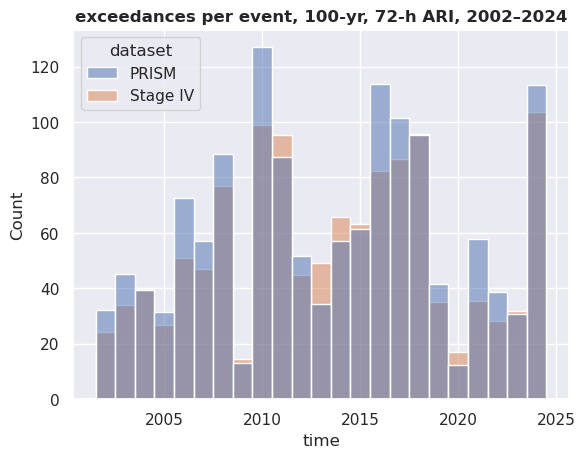

In [114]:
sns.histplot(yeardist, x='time', hue='dataset', weights='weight', #ax=axes['pointsper_short'],
             bins = list(np.arange(2001,2025) + 0.5)).set_title("exceedances per event, "+str(ari)+"-yr, "+str(duration)+"-h ARI, 2002\u20132024",
                                                  fontdict={'weight': 'semibold'})
#axes['pointsper_short'].set_xlim([2001, 2025])
#axes['pointsper_short'].set_xticks(range(2002,2025,4))
#axes['pointsper_short'].set_xlabel('year')
#axes['pointsper_short'].set_ylabel('')

## 2-panel, SW region

In [115]:
region = "SW"

min_lat_dict = {'PCST': 34.4, 'SW': 31.3, 'ROCK': 39.0, 'SGP': 27.5, 'NGP': 39.0, 'MDWST': 36.5, 'SE': 29.0, 'NE': 36.5, 'FL': 25.0,'CONUS': 25.0}
max_lat_dict = {'PCST': 49.0, 'SW': 39.0, 'ROCK': 49.0, 'SGP': 39.0, 'NGP': 49.0, 'MDWST': 46.5, 'SE': 36.5, 'NE': 45.0, 'FL': 29.0,'CONUS': 49.0}
min_lon_dict = {'PCST': 235.8, 'SW': 240.0, 'ROCK': 240.0, 'SGP': 255.0, 'NGP': 255.0, 'MDWST': 265.4, 'SE': 265.4, 'NE': 279.5, 'FL': 277.0,'CONUS': 235.8}
max_lon_dict = {'PCST': 240.0, 'SW': 255.0, 'ROCK': 255.0, 'SGP': 265.4, 'NGP': 265.4, 'MDWST': 279.5, 'SE': 282.2, 'NE': 290.0, 'FL': 280.2,'CONUS': 290.0}

latmin = min_lat_dict[region]
latmax = max_lat_dict[region]
lonmin = min_lon_dict[region] - 360.
lonmax = max_lon_dict[region] - 360.

print(latmin,latmax,lonmin,lonmax)

st4 = st4[(st4.lon >= lonmin) & (st4.lon <= lonmax) & (st4.lat >= latmin) & (st4.lat <= latmax)] 
conus404 = conus404[(conus404.lon >= lonmin) & (conus404.lon <= lonmax) & (conus404.lat >= latmin) & (conus404.lat <= latmax)] 
prism = prism[(prism.lon >= lonmin) & (prism.lon <= lonmax) & (prism.lat >= latmin) & (prism.lat <= latmax)] 
mrms = mrms[(mrms.lon >= lonmin) & (mrms.lon <= lonmax) & (mrms.lat >= latmin) & (mrms.lat <= latmax)] 

st4

31.3 39.0 -120.0 -105.0


,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
205,2002-06-23 12:00:00,34.41667,-105.75000,135.597,19.643,1.16941,3
206,2002-06-23 12:00:00,34.41667,-105.70833,148.313,31.623,1.27100,3
207,2002-06-23 12:00:00,34.45833,-105.75000,139.410,23.838,1.20626,3
208,2002-06-23 12:00:00,34.45833,-105.70833,178.536,62.534,1.53907,3
209,2002-06-23 12:00:00,34.45833,-105.66667,158.854,42.903,1.37001,3
...,...,...,...,...,...,...,...
63967,2024-10-21 12:00:00,37.16667,-105.79167,75.512,6.935,1.10112,0
63968,2024-10-21 12:00:00,37.16667,-105.75000,70.411,1.351,1.01956,0
63969,2024-10-21 12:00:00,37.20833,-105.83333,78.882,11.551,1.17156,0
63970,2024-10-21 12:00:00,37.20833,-105.79167,80.681,13.196,1.19554,0


In [116]:
prism_sub = prism[prism.time < pd.Timestamp(2022,10,1,0)]
### shorter period
st4_sub = st4[st4.time < pd.Timestamp(2022,10,1,0)]
conus404_sub = conus404[(conus404.time >= pd.Timestamp(2002,1,1,0))]

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_long = pd.concat([prism_yeardist_events,conus404_yeardist_events])
yeardist_events_long.columns=['year','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_sub_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_short = pd.concat([st4_yeardist_events,conus404_sub_yeardist_events])
yeardist_events_short.columns=['year','dataset']

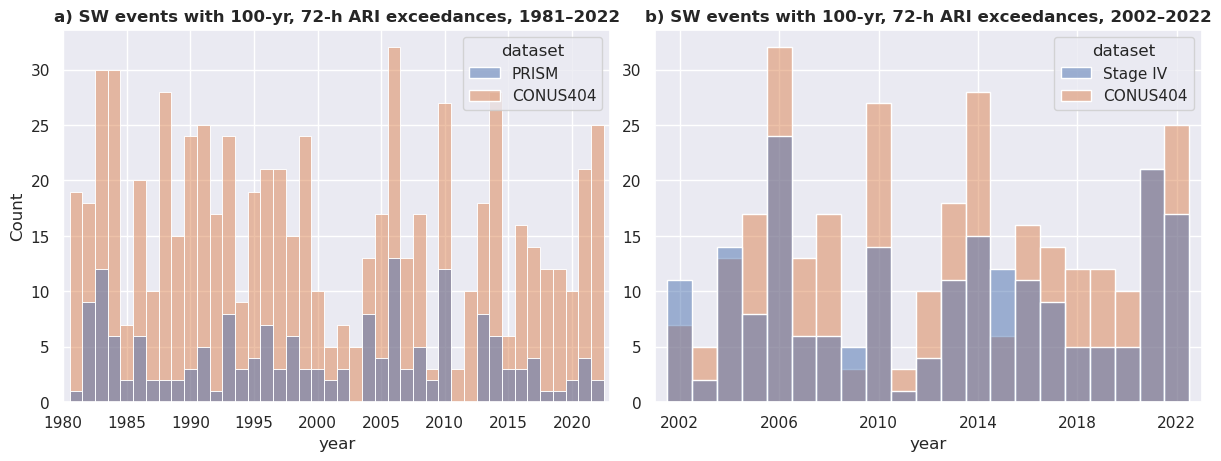

In [117]:
fig, axes = plt.subplot_mosaic([['long','short']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(yeardist_events_long, x='year', hue='dataset', ax=axes['long'],
             bins = np.arange(1980,2023) + 0.5).set_title("a) "+region+" events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['long'].set_xlim([1980, 2023])
### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(yeardist_events_short, x='year', hue='dataset', ax=axes['short'],
             bins = np.arange(2001,2025) + 0.5).set_title("b) "+region+" events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['short'].set_xticks(range(2002,2023,4))
axes['short'].set_xlim(2001,2023)
axes['short'].set_ylabel('')
### put numbers on top of the bars
#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("annual_dist_events_compare_2panel_"+region+"_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')
plt.show()
plt.close('all')

In [118]:
prism_yeardist_events

,0,dataset
0,1981,PRISM
1,1982,PRISM
2,1982,PRISM
3,1982,PRISM
4,1982,PRISM
...,...,...
169,2021,PRISM
170,2021,PRISM
171,2021,PRISM
172,2022,PRISM


In [119]:
conus404_yeardist_events[conus404_yeardist_events[0]==2014]

,0,dataset
556,2014,CONUS404
557,2014,CONUS404
558,2014,CONUS404
559,2014,CONUS404
560,2014,CONUS404
561,2014,CONUS404
562,2014,CONUS404
563,2014,CONUS404
564,2014,CONUS404
565,2014,CONUS404


In [120]:
#conus404_sub[conus404_sub.time=="2006-06-28 12:00:00"]